# LINMA1702 — Gestion optimale d'un barrage hydroélectrique
## Partie 1

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from hydro import hydro, parse_scenario, reference_strategy_revenue, no_pump_revenue

---
## Q1.3 — Analyse exploratoire des données

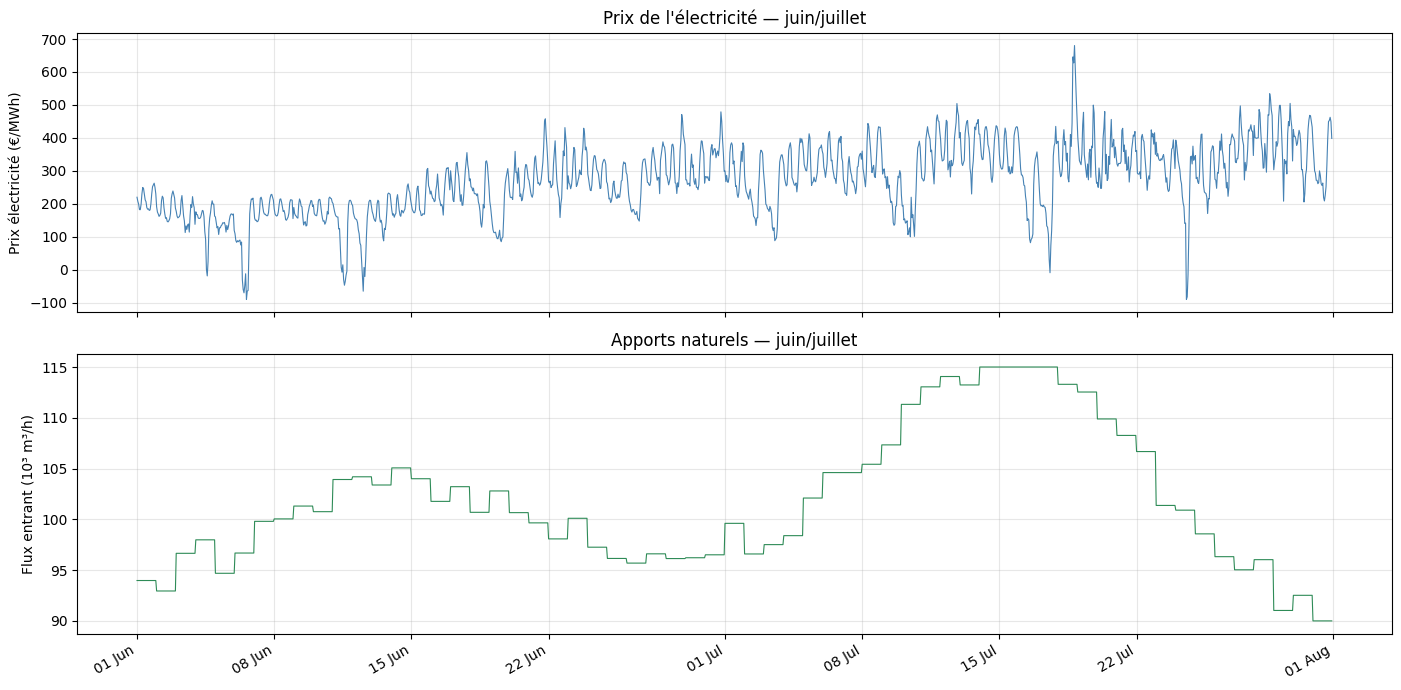

Prix moyen  : 271.05 €/MWh
Prix max    : 680.28 €/MWh
Prix min    : -90.00 €/MWh
Flux moyen  : 101921 m³/h


In [7]:
params = parse_scenario("../data/BelgiumScenario1.txt")
N = params["N"]
P = params["P"]
F = params["F"]

# Build time axis starting 1 June
t0 = datetime(2024, 6, 1)
times = [t0 + timedelta(hours=k) for k in range(N)]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(times, P, color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Prix électricité (€/MWh)")
axes[0].set_title("Prix de l'électricité — juin/juillet")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, F / 1e3, color="seagreen", linewidth=0.8)
axes[1].set_ylabel("Flux entrant (10³ m³/h)")
axes[1].set_title("Apports naturels — juin/juillet")
axes[1].grid(True, alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("exploratory_analysis.pdf", bbox_inches="tight")
plt.show()

print(f"Prix moyen  : {P.mean():.2f} €/MWh")
print(f"Prix max    : {P.max():.2f} €/MWh")
print(f"Prix min    : {P.min():.2f} €/MWh")
print(f"Flux moyen  : {F.mean():.0f} m³/h")

---
## Q1.4 & Q1.5 — Résolution et comparaison avec la stratégie de référence

In [8]:
# ── solve optimal ──────────────────────────────────────────────────────────────
sol = hydro("../data/BelgiumScenario1.txt")

print(f"Valeur optimale (avec pompage)  : {sol['valopt']:,.0f} €")
print(f"Statut solveur                  : {sol['problem'].status}")

Valeur optimale (avec pompage)  : 11,083,291 €
Statut solveur                  : optimal


In [9]:
# ── reference and no-pump revenues ────────────────────────────────────────────
rev_ref     = reference_strategy_revenue(sol["params"])
rev_no_pump = no_pump_revenue(sol)
rev_opt     = sol["valopt"]

print(f"Stratégie de référence (T=F, sans pompage) : {rev_ref:,.0f} €")
print(f"Optimisation sans pompage                  : {rev_no_pump:,.0f} €")
print(f"Optimisation avec pompage                  : {rev_opt:,.0f} €")
print()
print(f"Gain de l'optimisation (vs référence)      : {rev_opt - rev_ref:,.0f} €")
print(f"Gain spécifique du pompage                 : {rev_opt - rev_no_pump:,.0f} €")

Stratégie de référence (T=F, sans pompage) : 8,119,554 €
Optimisation sans pompage                  : 9,589,005 €
Optimisation avec pompage                  : 11,083,291 €

Gain de l'optimisation (vs référence)      : 2,963,737 €
Gain spécifique du pompage                 : 1,494,286 €


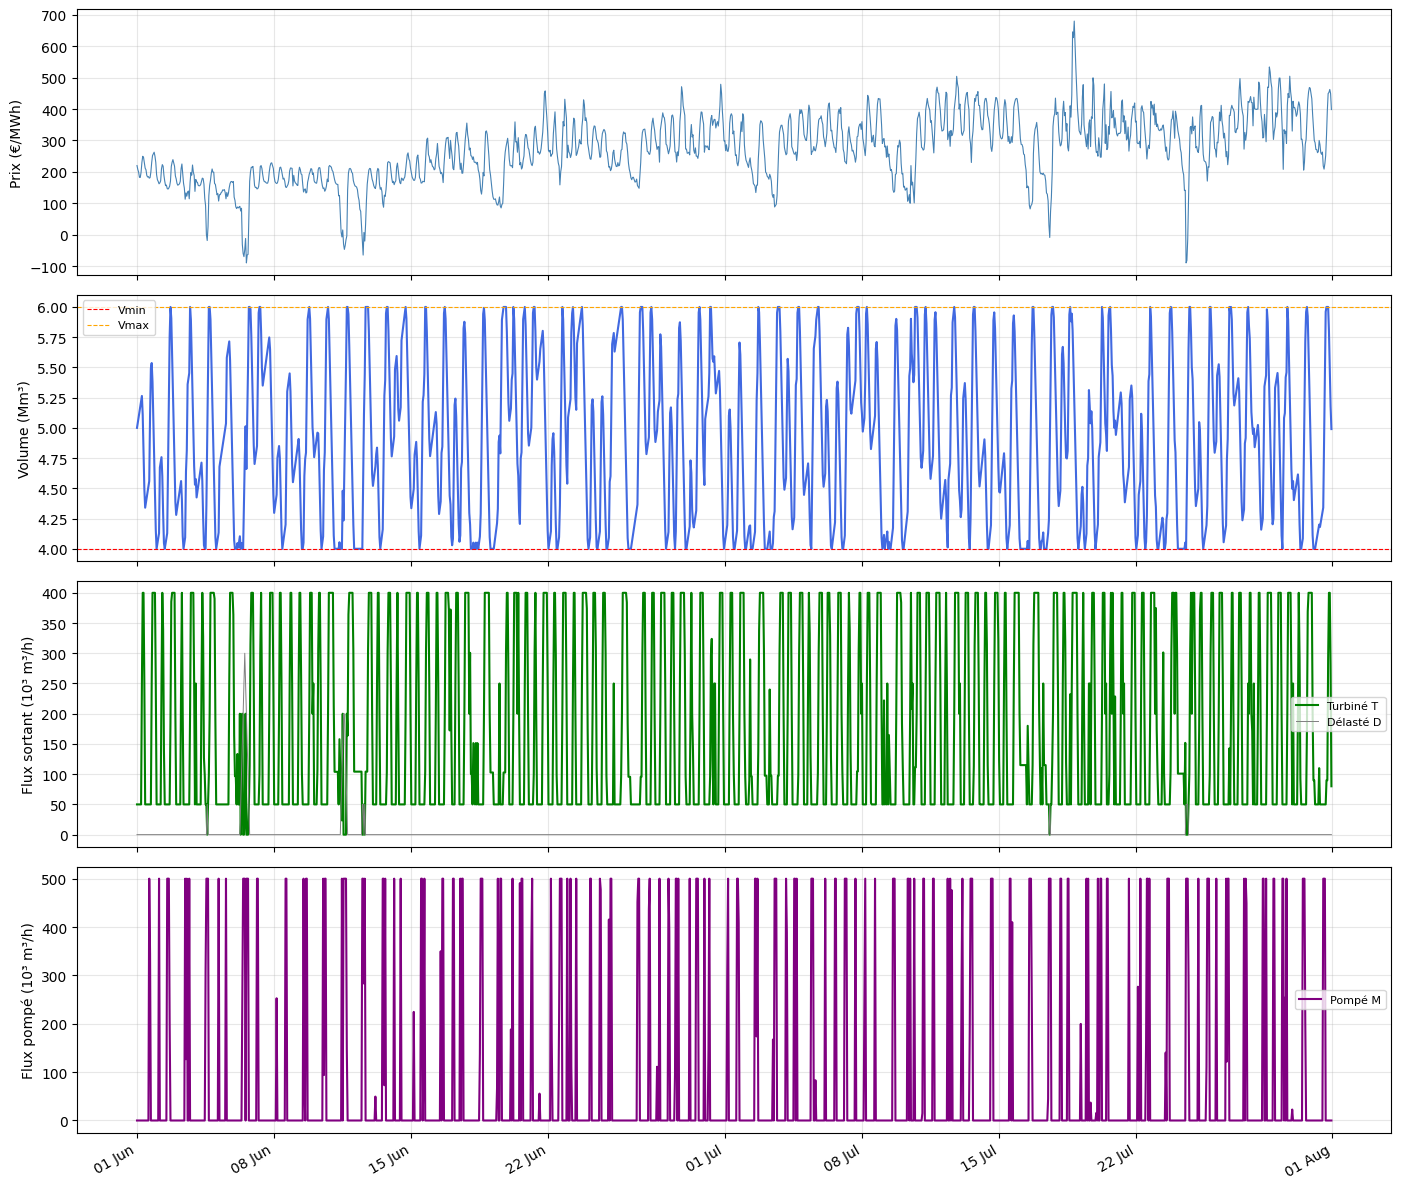

In [10]:
# ── plot optimal solution ──────────────────────────────────────────────────────
T_opt = sol["T"]
D_opt = sol["D"]
M_opt = sol["M"]
V_opt = sol["V"]
params = sol["params"]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(times, params["P"], color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Prix (€/MWh)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, V_opt[:-1] / 1e6, color="royalblue")
axes[1].axhline(params["Vmin"] / 1e6, color="red",   linestyle="--", linewidth=0.8, label="Vmin")
axes[1].axhline(params["Vmax"] / 1e6, color="orange", linestyle="--", linewidth=0.8, label="Vmax")
axes[1].set_ylabel("Volume (Mm³)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(times, T_opt / 1e3, color="green",  label="Turbiné T")
axes[2].plot(times, D_opt / 1e3, color="gray",   label="Délasté D", linewidth=0.7)
axes[2].set_ylabel("Flux sortant (10³ m³/h)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

axes[3].plot(times, M_opt / 1e3, color="purple", label="Pompé M")
axes[3].set_ylabel("Flux pompé (10³ m³/h)")
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("optimal_solution.pdf", bbox_inches="tight")
plt.show()

---
## Q1.6 — Analyse de sensibilité (prix duaux)

In [12]:
"""
CVXPY exposes dual values via constraint.dual_value.
For a maximisation problem, the dual of a constraint  g(x) <= b  equals
  dOpt/db  (sensitivity of objective to relaxing the bound by 1 unit).

We re-build the problem keeping explicit references to each constraint
so we can read their duals after solving.
"""
import cvxpy as cp
from hydro import parse_scenario, DELTA_T, DEFAULT_SOLVER

params = parse_scenario("../data/BelgiumScenario1.txt")
N  = params["N"]
F  = params["F"]
P  = params["P"]
ET = params["ET"]
ME = params["ME"]
dt = DELTA_T

T = cp.Variable(N, nonneg=True)
D = cp.Variable(N, nonneg=True)
M = cp.Variable(N, nonneg=True)
V = cp.Variable(N + 1, nonneg=True)

# --- keep named references for dual extraction
c_V0       = V[0]  == params["V0"]
c_VN       = V[N]  == params["V0"]
c_Vmax     = V     <= params["Vmax"]
c_Vmin     = V     >= params["Vmin"]
c_Tmax     = T     <= params["Tmax"]
c_Dmax     = D     <= params["Dmax"]
c_Mmax     = M     <= params["Mmax"]
c_TDmin    = T + D >= params["TDmin"]

dynamics = [V[k+1] == V[k] + (F[k] + M[k] - T[k] - D[k]) * dt for k in range(N)]

ramp_T = []
ramp_D = []
for k in range(1, N):
    ramp_T += [T[k] - T[k-1] <=  params["VTmax"] * dt,
               T[k-1] - T[k] <=  params["VTmax"] * dt]
    ramp_D += [D[k] - D[k-1] <=  params["VDmax"] * dt,
               D[k-1] - D[k] <=  params["VDmax"] * dt]

all_constraints = ([c_V0, c_VN, c_Vmax, c_Vmin, c_Tmax, c_Dmax, c_Mmax, c_TDmin]
                   + dynamics + ramp_T + ramp_D)

objective = cp.sum(cp.multiply(P, ET * T - ME * M)) * dt
problem   = cp.Problem(cp.Maximize(objective), all_constraints)
problem.solve(solver=DEFAULT_SOLVER, verbose=False)

print(f"Objectif optimal : {problem.value:,.0f} €\n")

# Aggregate dual of Vmax: sum over binding steps, then express per m³
dual_Vmax  = np.sum(c_Vmax.dual_value)   # €/m³  (total sensitivity)
dual_Tmax  = np.sum(c_Tmax.dual_value)   # €/(m³/h)
dual_Mmax  = np.sum(c_Mmax.dual_value)
dual_VTmax = np.sum([c.dual_value for c in ramp_T])  # €/(m³/h²)·h = €·h/m³

print("Sensibilités (valeurs duales agrégées) :")
print(f"  dOpt/dVmax  = {dual_Vmax:.4f} €/m³")
print(f"  dOpt/dTmax  = {dual_Tmax:.4f} €/(m³/h)")
print(f"  dOpt/dMmax  = {dual_Mmax:.4f} €/(m³/h)")
print(f"  dOpt/dVTmax = {dual_VTmax:.4f} €·h/m³")

Objectif optimal : 11,083,291 €

Sensibilités (valeurs duales agrégées) :
  dOpt/dVmax  = 0.5650 €/m³
  dOpt/dTmax  = 3.0147 €/(m³/h)
  dOpt/dMmax  = 0.9903 €/(m³/h)
  dOpt/dVTmax = 0.6871 €·h/m³


In [13]:
# ── Sensitivity to F[k] and P[k] via dynamics dual values ────────────────────
# dual of dynamics constraint k = dOpt/dF[k]  (water price, €/m³)
dual_F = np.array([c.dual_value for c in dynamics])
# dual of P[k]: ET * T[k].value * dt  (already known analytically)
dual_P = ET * T.value * dt

print("\nSensibilité à F[k] (prix de l'eau, €/m³) :")
print(f"  min={dual_F.min():.4f}  mean={dual_F.mean():.4f}  max={dual_F.max():.4f}")

print("\nSensibilité à P[k] (€ par unité de €/MWh, ×ΔP·MWh) :")
print(f"  min={dual_P.min():.2f}  mean={dual_P.mean():.2f}  max={dual_P.max():.2f}")


Sensibilité à F[k] (prix de l'eau, €/m³) :
  min=-0.0095  mean=0.0565  max=0.0848

Sensibilité à P[k] (€ par unité de €/MWh, ×ΔP·MWh) :
  min=0.00  mean=34.49  max=80.00


In [ ]:
# ── Q1.6c — large perturbation: compare linear estimate vs re-optimisation ────
DELTA_VMAX = 500_000  # m³  — large perturbation

linear_estimate = dual_Vmax * DELTA_VMAX

params_perturbed = dict(params)
params_perturbed["Vmax"] += DELTA_VMAX

# Re-solve with modified Vmax
import tempfile, os

# Quick re-solve using hydro() helper with a patched params dict (inline solve)
T2 = cp.Variable(N, nonneg=True)
D2 = cp.Variable(N, nonneg=True)
M2 = cp.Variable(N, nonneg=True)
V2 = cp.Variable(N + 1, nonneg=True)

dyn2  = [V2[k+1] == V2[k] + (F[k] + M2[k] - T2[k] - D2[k]) * dt for k in range(N)]
rT2   = [c for k in range(1, N)
         for c in [T2[k]-T2[k-1] <= params["VTmax"]*dt, T2[k-1]-T2[k] <= params["VTmax"]*dt]]
rD2   = [c for k in range(1, N)
         for c in [D2[k]-D2[k-1] <= params["VDmax"]*dt, D2[k-1]-D2[k] <= params["VDmax"]*dt]]

c2 = ([V2[0] == params["V0"], V2[N] == params["V0"],
       V2 <= params_perturbed["Vmax"], V2 >= params["Vmin"],
       T2 <= params["Tmax"], D2 <= params["Dmax"], M2 <= params["Mmax"],
       T2 + D2 >= params["TDmin"]]
      + dyn2 + rT2 + rD2)

obj2  = cp.sum(cp.multiply(P, ET * T2 - ME * M2)) * dt
prob2 = cp.Problem(cp.Maximize(obj2), c2)
prob2.solve(solver=DEFAULT_SOLVER, verbose=False)

real_gain = prob2.value - problem.value

print(f"ΔVmax = {DELTA_VMAX:,} m³")
print(f"Estimation linéaire : {linear_estimate:,.0f} €")
print(f"Gain réel (re-optimisation) : {real_gain:,.0f} €")
print(f"Erreur relative : {abs(real_gain - linear_estimate)/abs(real_gain)*100:.1f} %")

ΔVmax = 500,000 m³
Estimation linéaire : 282,510 €
Gain réel (re-optimisation) : 256,097 €
Erreur relative : 10.3 %
